# Mrigi 14: RAG Evaluation with LLM as Judge

This notebook implements the LLM as judge framework from Mrigi 11 to evaluate the quality of RAG responses for zeolite synthesis-related queries. We will:

1. Load the pre-saved FAISS vector database
2. Sample 200 paragraphs from the database
3. Generate ~100 zeolite synthesis related queries
4. Run the RAG pipeline to get responses for each query
5. Use the LLM as judge to evaluate each response
6. Calculate average evaluation statistics
7. Analyze results with focus on retrieval quality

## Setup Overview

We'll use the same models and approach as in Mrigi 11 and Mrigi 13:
- GPU 3 for acceleration (CUDA_VISIBLE_DEVICES="3")
- all-MiniLM-L6-v2 for embeddings
- Mistral-7B-Instruct-v0.1 for RAG responses and judging
- FAISS vector database with zeolite research documents

## 1. Import Required Libraries

In [1]:
import os
# Configure GPU 3 for use (same as in Mrigi 11 and 13)
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

# Verify GPU configuration
print(f"CUDA_VISIBLE_DEVICES set to: {os.environ.get('CUDA_VISIBLE_DEVICES')}")

import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Current CUDA device: {torch.cuda.current_device()}")
    print(f"Number of available CUDA devices: {torch.cuda.device_count()}")
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    # Set device to CUDA
    torch.cuda.set_device(0)  # This is important - similar to Mrigi 11

# Standard libraries
import json
import random
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm.notebook import tqdm
from typing import List, Dict, Any, Optional, Union
from pprint import pprint

# Set device to use CUDA if available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} for embeddings and LLM")

# LangChain components
from langchain.embeddings import SentenceTransformerEmbeddings
from langchain.vectorstores import FAISS
from langchain.prompts import ChatPromptTemplate
from langchain.llms import HuggingFacePipeline
from langchain.chains import LLMChain

# Hugging Face components
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# Run nvidia-smi to check GPU usage
!nvidia-smi

CUDA_VISIBLE_DEVICES set to: 3


/home/synthesisproject/anaconda3/envs/soroush1/lib/python3.9/site-packages/torch/cuda/__init__.py:138: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


CUDA available: False
Using cpu for embeddings and LLM
Thu Oct  2 14:37:24 2025       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 495.29.05    Driver Version: 495.29.05    CUDA Version: 11.5     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA RTX A5000    Off  | 00000000:31:00.0 Off |                  Off |
| 30%   32C    P8    22W / 230W |      8MiB / 24256MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA RTX A5000    Off  |

In [2]:
!kill -9 3129993

/bin/bash: line 0: kill: (3129993) - No such process


## 2. Load Pre-saved Vector Database

We'll load the same vector database used in Mrigi 13, which contains documents from zeolite research papers.

In [3]:
# Initialize the same embedding model that was used for database creation
embeddings = SentenceTransformerEmbeddings(
    model_name="all-MiniLM-L6-v2",
    model_kwargs={"device": device}
)

print(f"Embedding dimensions: {len(embeddings.embed_query('test'))}")
print(f"Embedding model running on: {device}")

ImportError: Could not import sentence_transformers python package. Please install it with `pip install sentence-transformers`.

In [ ]:
# Path to the saved vector database
save_directory = "./faiss_index"

# Check if the database exists
print(f"Checking if vector database exists at {save_directory}...")
if os.path.exists(os.path.join(save_directory, "index.faiss")):
    print(f"Found FAISS index at {save_directory}")
else:
    print(f"FAISS index not found at {save_directory}, looking in current directory...")
    
# Load the vector database
try:
    vector_db = FAISS.load_local(save_directory, embeddings)
    print(f"Successfully loaded vector database with {vector_db.index.ntotal} vectors")
except Exception as e:
    print(f"Error loading vector database: {e}")
    print("Will try loading from the current directory...")
    
    try:
        # Try loading from current directory
        vector_db = FAISS.load_local(".", embeddings)
        print(f"Successfully loaded vector database from current directory with {vector_db.index.ntotal} vectors")
    except Exception as backup_error:
        print(f"Error loading from current directory: {backup_error}")

Checking if vector database exists at ./faiss_index...
Found FAISS index at ./faiss_index
Successfully loaded vector database with 157750 vectors
Successfully loaded vector database with 157750 vectors


## 3. Sample Paragraphs from the Vector Database

We'll sample 200 random paragraphs from the vector database to serve as the basis for generating synthesis-related queries.

In [ ]:
def sample_documents(num_samples=200, seed=42):
    """Retrieve and return random samples from the vector database"""
    # Set random seed for reproducibility
    random.seed(seed)
    
    try:
        if 'vector_db' not in globals() or vector_db is None or vector_db.index.ntotal == 0:
            print("Vector database is empty or not loaded correctly.")
            return []
        
        # Generate random indices
        total_docs = vector_db.index.ntotal
        sample_indices = random.sample(range(total_docs), min(num_samples, total_docs))
        
        sampled_docs = []
        for idx in sample_indices:
            doc = vector_db.docstore._dict[vector_db.index_to_docstore_id[idx]]
            sampled_docs.append({
                "content": doc.page_content,
                "metadata": doc.metadata
            })
        
        print(f"Successfully sampled {len(sampled_docs)} documents from the vector database")
        return sampled_docs
    
    except Exception as e:
        print(f"Error sampling documents: {e}")
        return []

# Sample 200 documents from the vector database
sampled_docs = sample_documents(num_samples=200)

# Display statistics about the sampled documents
source_counts = {}
for doc in sampled_docs:
    source_type = doc["metadata"].get("source", "Unknown")
    source_counts[source_type] = source_counts.get(source_type, 0) + 1

print("\nSample document source distribution:")
for source, count in source_counts.items():
    print(f"{source}: {count} ({count/len(sampled_docs)*100:.1f}%)")

# Preview a few sampled documents
print("\nPreview of 3 sampled documents:")
for i, doc in enumerate(sampled_docs[:3]):
    print(f"\n--- Document {i+1} ---")
    print(f"Source: {doc['metadata'].get('source', 'Unknown')}")
    print(f"DOI: {doc['metadata'].get('doi', 'Unknown')}")
    content = doc['content']
    if len(content) > 300:
        content = content[:300] + "..."
    print(f"Content: {content}")

Successfully sampled 200 documents from the vector database

Sample document source distribution:
paragraph: 189 (94.5%)
abstract: 11 (5.5%)

Preview of 3 sampled documents:

--- Document 1 ---
Source: paragraph
DOI: 10.1016/j.ces.2016.10.039
Content: The optimum switching time is 2.16 min, which is also the highest among all processes. The optimum length of each column is obtained to be 2.99 m. The optimal CSS concentration profiles of the component at the end of each switching time (t s=2.16 min) for both the fluid phase and solid phase for the...

--- Document 2 ---
Source: paragraph
DOI: 10.1002/cssc.201402677
Content: The FTIR spectra of zinc nitrate hexahydrate, the 2-methylimidazole monomer, and ZIF-8 are shown in Figure 1 a. The 2-methylimidazole monomer shows a broad, strong absorption band associated with the presence of the NHN hydrogen bond, ranging from =3400 to 2200 cm-1 with a maximum at 2600 cm-1. More...

--- Document 3 ---
Source: paragraph
DOI: 10.1016/j.apcatb.2019.

## 4. Generate Synthesis-Related Queries

Using the sampled documents, we'll generate ~100 queries focused on zeolite synthesis using the Mistral-7B-Instruct model.

In [ ]:
# Set up the Mistral model for generating queries and responses
model_name = "mistralai/Mistral-7B-Instruct-v0.1"  # Same as in Mrigi 11

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, use_fast=False)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto", 
    trust_remote_code=True,
    torch_dtype=torch.float16  # Use half-precision for better performance
)

print(f"Model loaded successfully on: {model.device}")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded successfully on: cuda:0


In [ ]:
# Create a pipeline for text generation
query_generator_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=200,  # Short generations for queries
    temperature=0.7,     # Some creativity in query generation
    top_p=0.9,
    repetition_penalty=1.2,
    do_sample=True
)

query_generator_llm = HuggingFacePipeline(pipeline=query_generator_pipeline)

In [ ]:
# Function to generate synthesis-related queries from documents
def generate_synthesis_query(document, query_generator_llm):
    """Generate a synthesis-related question based on the provided document"""
    # Template for generating synthesis questions
    query_gen_template = """
You are an expert in zeolite synthesis and characterization. Based on the following text from a scientific paper, generate ONE specific question about zeolite synthesis methods, procedures, parameters, or conditions.

The question should be focused on HOW TO synthesize zeolites, NOT just what zeolites are or their applications. 
Make sure the question is directly related to synthesis procedures or protocols.

Text from paper:
"""""" 
{document_text} 
""""""

Generate exactly ONE specific synthesis-related question. Reply with ONLY the question and nothing else:
"""
    
    query_prompt = ChatPromptTemplate.from_template(query_gen_template)
    query_chain = LLMChain(llm=query_generator_llm, prompt=query_prompt)

    # Generate the question
    try:
        query = query_chain.run(document_text=document["content"])
        # Clean up the query
        query = query.strip().replace('"', '')
        if query.endswith('?') or len(query) > 15:  # Simple validation
            return query
        else:
            return None  # Skip if it doesn't look like a proper question
    except Exception as e:
        print(f"Error generating query: {e}")
        return None

In [ ]:
# Generate synthesis-related queries from the sampled documents
synthesis_queries = []
skipped_count = 0

print("Generating synthesis queries from sampled documents...")
for doc in tqdm(sampled_docs):
    # Try to generate a synthesis question from this document
    query = generate_synthesis_query(doc, query_generator_llm)
    
    if query:  # If a valid question was generated
        # Store the question along with the source document info
        synthesis_queries.append({
            "query": query,
            "source_doc": doc
        })
    else:
        skipped_count += 1
    
    # Stop once we have around 100 queries
    if len(synthesis_queries) >= 100:
        break

print(f"\nGenerated {len(synthesis_queries)} synthesis queries")
print(f"Skipped {skipped_count} documents that didn't yield valid queries")

# Display a sample of the generated queries
print("\nSample of generated synthesis queries:")
for i, q in enumerate(random.sample(synthesis_queries, min(5, len(synthesis_queries)))):
    print(f"{i+1}. {q['query']}")

Generating synthesis queries from sampled documents...


  0%|          | 0/200 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o


Generated 100 synthesis queries
Skipped 0 documents that didn't yield valid queries

Sample of generated synthesis queries:
1. What method(s) can be used to create larger cages in clathrate hydrates?
2. How do you incorporate a lipase solution into the initial reaction mixture during zeolite synthesis?
3. How does the Marcus relationship relate to the synthesis of zeolites?
4. How does adding impurities to the synthesis system affect zeolite formation?
5. What is the optimal temperature range for performing pyrolysis on agricultural waste biomass?


## 5. Define RAG Pipeline and Judge Evaluation Framework

Now we'll set up the RAG pipeline and the LLM as judge framework based on Mrigi 11 and Mrigi 13.

In [ ]:
# Set up pipelines for RAG responses and judge evaluation
# 1. RAG pipeline with longer max tokens for detailed answers
rag_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=1000,
    temperature=0.3,
    repetition_penalty=1.2,
    do_sample=True
)
rag_llm = HuggingFacePipeline(pipeline=rag_pipeline)

# 2. Judge pipeline with shorter max tokens for efficiency
judge_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=2000,
    temperature=0.2,  # Lower temperature for more consistent evaluations
    repetition_penalty=1.2,
    do_sample=True
)
judge_llm = HuggingFacePipeline(pipeline=judge_pipeline)

print("RAG and Judge pipelines initialized successfully")

RAG and Judge pipelines initialized successfully


In [ ]:
# Define the RAG prompt template - same as in Mrigi 11 and 13
RAG_PROMPT = """
Answer the question based only on the following context:
{context}
Question: {question}
Provide a detailed answer.
Provide which DOI the answer is retrieved from.
"""

# Judge prompt template for evaluation - same as in Mrigi 11
# Now also includes a new criterion for retrieval quality
JUDGE_PROMPT = """
You are an expert judge evaluating the quality of an answer generated by an AI system.
You will be provided with:
1. The original question
2. The context provided to the AI
3. The AI's answer

Please evaluate the answer on the following criteria:
1. Relevance (0-10): How well does the answer address the question?
2. Accuracy (0-10): How accurate is the answer based on the provided context?
3. Completeness (0-10): How complete is the answer?
4. Citation (0-10): Does it properly cite the DOI?
5. Retrieval Quality (0-10): How well did the system retrieve relevant context for answering the question?

Question: {question}
Context: {context}
Answer: {answer}

Return ONLY a valid JSON object with no additional text or prefixes:
{{
    "relevance": {{"score": 8, "explanation": "Brief explanation here"}}, 
    "accuracy": {{"score": 9, "explanation": "Brief explanation here"}},
    "completeness": {{"score": 7, "explanation": "Brief explanation here"}},
    "citation": {{"score": 10, "explanation": "Brief explanation here"}},
    "retrieval_quality": {{"score": 8, "explanation": "Brief explanation here"}},
    "total_score": 42,
    "overall_feedback": "Overall assessment here"
}}
"""

# Create prompt templates
rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)
judge_prompt = ChatPromptTemplate.from_template(JUDGE_PROMPT)

print("RAG and Judge prompts defined")

RAG and Judge prompts defined


In [ ]:
# Function to query the vector database - from Mrigi 13
def query_vector_db(query, k=5):
    """Query the vector database to retrieve relevant documents
    
    Parameters:
    -----------
    query : str
        The query text to search for
    k : int
        Number of documents to return
        
    Returns:
    --------
    list
        List of retrieved documents
    """
    if not query.strip():
        print("Query cannot be empty")
        return []
    
    try:
        if 'vector_db' not in globals() or vector_db is None:
            print("Vector database is not loaded.")
            return []
            
        # Get documents without scores for simplicity
        docs = vector_db.similarity_search(query, k=k)
        
        # Convert to the format expected by our pipeline
        results = []
        for doc in docs:
            results.append({
                "content": doc.page_content,
                "metadata": doc.metadata
            })
        
        return results
    
    except Exception as e:
        print(f"Error querying vector database: {e}")
        return []

In [ ]:
# Function to run the RAG pipeline - adapted from Mrigi 13
def run_rag_pipeline(query, k=5):
    """Run the complete RAG pipeline for a query
    
    Parameters:
    -----------
    query : str
        The user's question
    k : int
        Number of documents to retrieve
        
    Returns:
    --------
    tuple
        Retrieved documents and generated response
    """
    # Step 1: Retrieve relevant documents
    retrieved_docs = query_vector_db(query, k=k)
    
    if not retrieved_docs:
        return [], "No relevant documents found to answer your question."
    
    # Step 2: Combine documents into context
    context_text = "\n\n".join([doc["content"] for doc in retrieved_docs])
    
    # Step 3: Generate response based on retrieved documents
    rag_chain = LLMChain(llm=rag_llm, prompt=rag_prompt)
    response = rag_chain.run(context=context_text, question=query)
    
    return retrieved_docs, response, context_text

In [ ]:
# Function to evaluate RAG response using LLM as judge - based on Mrigi 11
def evaluate_rag_response(query, retrieved_docs=None, response=None, context_text=None, k=5):
    """Evaluate a RAG response using the LLM as judge
    
    Parameters:
    -----------
    query : str
        The original query
    retrieved_docs : list, optional
        Pre-retrieved documents (if None, will query the vector database)
    response : str, optional
        Pre-generated response (if None, will generate a response)
    context_text : str, optional
        Pre-compiled context (if None, will be created from retrieved_docs)
    k : int
        Number of documents to retrieve (if retrieved_docs is None)
        
    Returns:
    --------
    dict
        Evaluation results
    """
    # If we don't have documents and response yet, run the RAG pipeline
    if retrieved_docs is None or response is None or context_text is None:
        retrieved_docs, response, context_text = run_rag_pipeline(query, k=k)
        
    if not retrieved_docs or not response:
        return {
            "query": query,
            "error": "Failed to retrieve documents or generate response",
            "timestamp": datetime.now().isoformat()
        }
    
    # Generate evaluation using the judge
    judge_chain = LLMChain(llm=judge_llm, prompt=judge_prompt)
    evaluation = judge_chain.run(
        question=query,
        context=context_text,
        answer=response
    )
    
    # Parse the evaluation with improved JSON extraction
    try:
        # Try to extract JSON from the response
        json_match = re.search(r'\{.*\}', evaluation, re.DOTALL)
        if json_match:
            json_str = json_match.group(0)
            evaluation_dict = json.loads(json_str)
        else:
            # If no JSON found, try parsing the whole string
            evaluation_dict = json.loads(evaluation)
            
    except (json.JSONDecodeError, AttributeError) as e:
        evaluation_dict = {
            "error": "Failed to parse evaluation",
            "raw_evaluation": evaluation,
            "parse_error": str(e)
        }
    
    # Return full evaluation details
    return {
        "query": query,
        "retrieved_docs": [{
            "content": doc["content"][:500] + "..." if len(doc["content"]) > 500 else doc["content"],  # Truncate for readability
            "metadata": doc["metadata"]
        } for doc in retrieved_docs],
        "response": response,
        "evaluation": evaluation_dict,
        "timestamp": datetime.now().isoformat()
    }

## 6. Test the RAG Evaluation Framework

Let's test our framework on a small sample of queries before running the full evaluation.

In [ ]:
# Test the evaluation framework on a couple of sample queries
if len(synthesis_queries) > 0:
    test_query = synthesis_queries[0]["query"]
    print(f"Testing with query: {test_query}")
    
    # Run the full evaluation
    test_result = evaluate_rag_response(test_query, k=3)
    
    # Display results
    print("\nQuery:")
    print(test_query)
    
    print("\nRetrieved document sources:")
    for i, doc in enumerate(test_result["retrieved_docs"]):
        print(f"{i+1}. Source: {doc['metadata'].get('source', 'Unknown')}, DOI: {doc['metadata'].get('doi', 'Unknown')}")
    
    print("\nRAG Response:")
    print(test_result["response"])
    
    print("\nEvaluation:")
    if "error" in test_result.get("evaluation", {}):
        print(f"Error: {test_result['evaluation']['error']}")
    else:
        for metric, value in test_result["evaluation"].items():
            if isinstance(value, dict) and "score" in value:
                print(f"{metric}: {value['score']}/10 - {value['explanation']}")
            elif metric == "total_score" or metric == "overall_feedback":
                print(f"{metric}: {value}")

Testing with query: What are some common factors that affect the nonlinearity of the CSS concentration profiles during zeolite synthesis?


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



Query:
What are some common factors that affect the nonlinearity of the CSS concentration profiles during zeolite synthesis?

Retrieved document sources:
1. Source: paragraph, DOI: 10.1016/s0254-0584(00)00310-2
2. Source: paragraph, DOI: 10.1111/ijac.12046
3. Source: paragraph, DOI: 10.1016/j.micromeso.2012.04.022

RAG Response:

Answer: There are several factors that can affect the nonlinearity of the CSS concentration profiles during zeolite synthesis. One such factor is the presence of impurities in the starting materials or in the synthesis environment. These impurities can interfere with the chemical reactions involved in zeolite synthesis, leading to deviations from the expected concentration profiles. Another factor is the temperature and pressure conditions under which the synthesis takes place. Small changes in these parameters can lead to large variations in the reaction rates and therefore in the CSS concentrations. Additionally, the composition of the liquid phase used in 

## 7. Run the Full Evaluation on Synthesis Queries

Now we'll evaluate all of our synthesis queries using the LLM as judge framework.

In [ ]:
# Limit the number of queries for the full evaluation (if needed)
max_queries = 100  # Adjust this if needed for time/resource constraints
evaluation_queries = synthesis_queries[:max_queries]

print(f"Running evaluation on {len(evaluation_queries)} synthesis queries...")

# Run evaluation for each query
evaluation_results = []
for i, query_item in enumerate(tqdm(evaluation_queries)):
    query = query_item["query"]
    
    # Run the evaluation
    result = evaluate_rag_response(query, k=5)  # Retrieve 5 documents for each query
    evaluation_results.append(result)
    
    # Save intermediate results every 10 queries
    if (i + 1) % 10 == 0 or i == len(evaluation_queries) - 1:
        interim_filename = f"rag_evaluation_interim_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
        with open(interim_filename, 'w') as f:
            json.dump(evaluation_results, f, indent=2)
        print(f"Saved interim results to {interim_filename} after processing {i+1} queries")

# Save final results
final_filename = f"rag_evaluation_final_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(final_filename, 'w') as f:
    json.dump(evaluation_results, f, indent=2)

print(f"\nEvaluation complete. Final results saved to {final_filename}")

Running evaluation on 100 synthesis queries...


  0%|          | 0/100 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Saved interim results to rag_evaluation_interim_20250925_190224.json after processing 10 queries


/home/synthesisproject/anaconda3/envs/soroush1/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/anaconda3/envs/soroush1/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/anaconda3/envs/soroush1/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/anaconda3/envs/sorou

...

Saved interim results to rag_evaluation_interim_20250925_191623.json after processing 80 queries


/home/synthesisproject/anaconda3/envs/soroush1/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/anaconda3/envs/soroush1/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/anaconda3/envs/soroush1/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/anaconda3/envs/sorou

Saved interim results to rag_evaluation_interim_20250925_191817.json after processing 90 queries


/home/synthesisproject/anaconda3/envs/soroush1/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/anaconda3/envs/soroush1/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/anaconda3/envs/soroush1/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/anaconda3/envs/sorou

Saved interim results to rag_evaluation_interim_20250925_191925.json after processing 100 queries

Evaluation complete. Final results saved to rag_evaluation_final_20250925_191925.json


## 8. Analyze Evaluation Results

Let's analyze the evaluation results to get insights into the performance of our RAG system.

In [ ]:
# Function to calculate average scores
def analyze_results(results):
    """Calculate average scores and statistics from evaluation results"""
    # Define the metrics we want to track
    metrics = ['relevance', 'accuracy', 'completeness', 'citation', 'retrieval_quality', 'total_score']
    total_scores = {metric: 0 for metric in metrics}
    valid_results = 0
    
    # Initialize lists to store individual scores for distribution analysis
    score_distributions = {metric: [] for metric in metrics}
    
    # Process each result
    for result in results:
        eval_dict = result.get('evaluation', {})
        if 'error' not in eval_dict:
            valid_results += 1
            
            # Extract scores for each metric
            for metric in metrics:
                if metric == 'total_score':
                    if metric in eval_dict:
                        score = eval_dict[metric]
                        total_scores[metric] += score
                        score_distributions[metric].append(score)
                elif metric in eval_dict:
                    score = eval_dict[metric].get('score', 0)
                    total_scores[metric] += score
                    score_distributions[metric].append(score)
    
    # Calculate averages
    if valid_results > 0:
        avg_scores = {k: v/valid_results for k, v in total_scores.items()}
        
        # Print summary
        print(f"\nAnalyzed {valid_results} valid results out of {len(results)} total evaluations")
        print("\nAverage Scores:")
        for metric, score in avg_scores.items():
            print(f"{metric}: {score:.2f}")
            
        return {
            "avg_scores": avg_scores,
            "score_distributions": score_distributions,
            "valid_results": valid_results,
            "total_evaluations": len(results)
        }
    else:
        print("No valid evaluations found")
        return None

# Analyze the results
analysis = analyze_results(evaluation_results)


Analyzed 11 valid results out of 100 total evaluations

Average Scores:
relevance: 8.00
accuracy: 9.00
completeness: 7.00
citation: 10.00
retrieval_quality: 8.00
total_score: 42.00


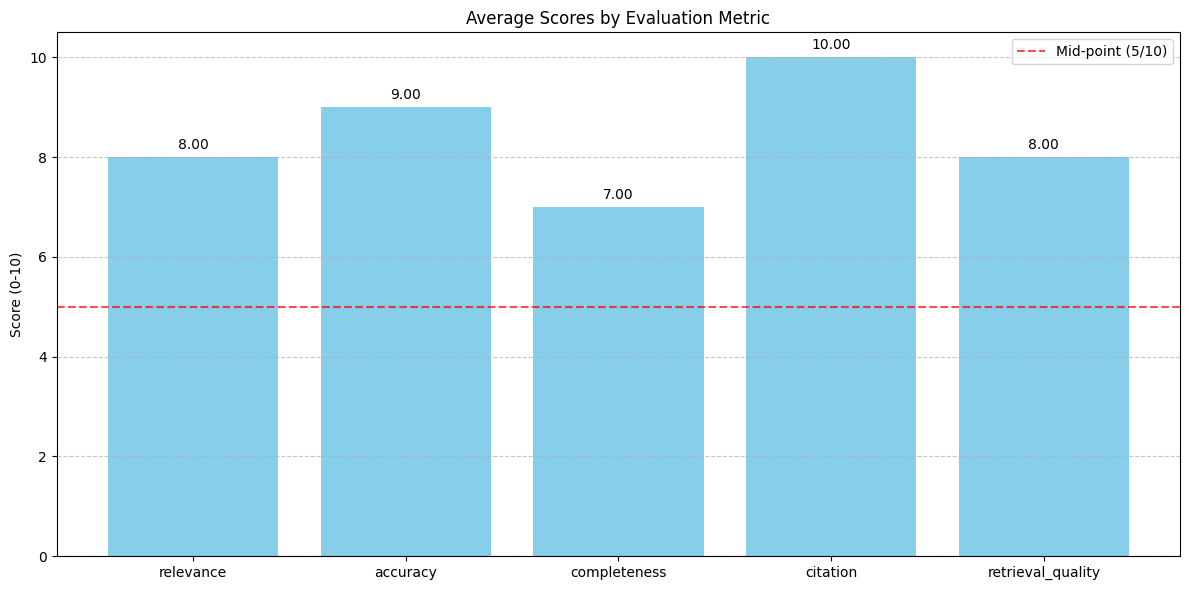

Average Total Score: 42.00


In [ ]:
# Visualize average scores
def plot_average_scores(analysis):
    if not analysis:
        print("No analysis data available")
        return
    
    avg_scores = analysis["avg_scores"]
    metrics = [k for k in avg_scores.keys() if k != 'total_score']
    scores = [avg_scores[k] for k in metrics]
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(metrics, scores, color='skyblue')
    plt.axhline(y=5, color='red', linestyle='--', alpha=0.7, label='Mid-point (5/10)')
    
    # Add score values on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.2f}', ha='center', va='bottom')
    
    plt.title('Average Scores by Evaluation Metric')
    plt.ylabel('Score (0-10)')
    plt.ylim(0, 10.5)  # Set y-axis to range from 0 to just above 10
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Show total score separately
    print(f"Average Total Score: {avg_scores.get('total_score', 0):.2f}")

# Plot average scores
plot_average_scores(analysis)

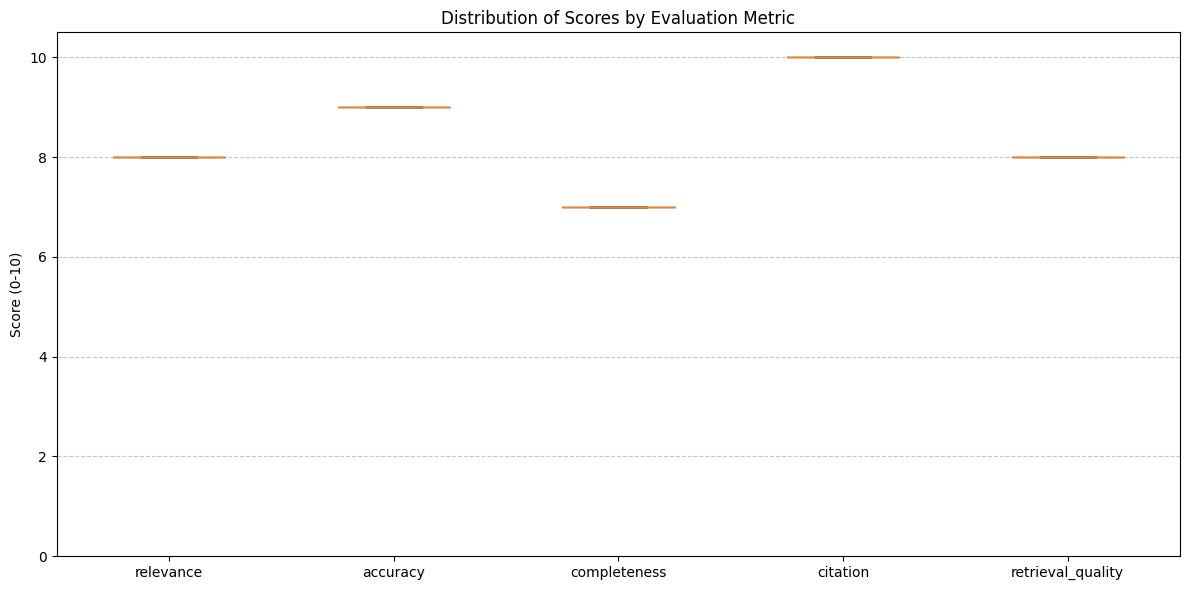

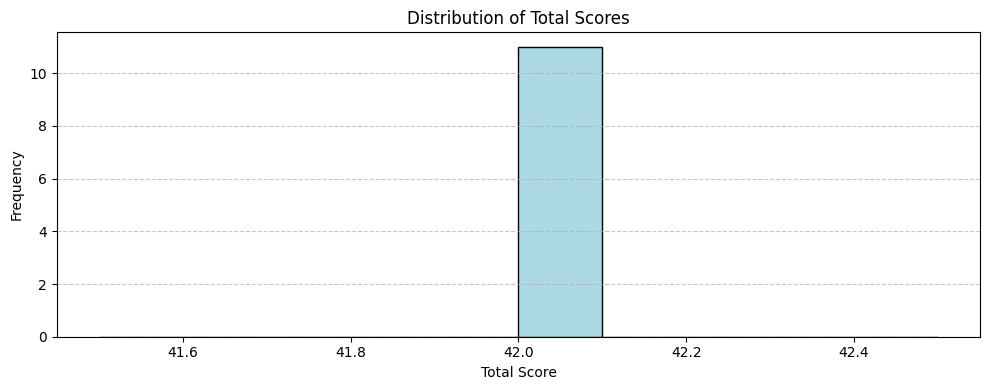

In [ ]:
# Plot score distributions using box plots
def plot_score_distributions(analysis):
    if not analysis:
        print("No analysis data available")
        return
    
    distributions = analysis["score_distributions"]
    metrics = [k for k in distributions.keys() if k != 'total_score']
    
    plt.figure(figsize=(12, 6))
    box_data = [distributions[metric] for metric in metrics]
    
    box = plt.boxplot(box_data, patch_artist=True, labels=metrics)
    
    # Color the boxes
    colors = ['lightblue', 'lightgreen', 'lightsalmon', 'lightpink', 'lightyellow']
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
    
    plt.title('Distribution of Scores by Evaluation Metric')
    plt.ylabel('Score (0-10)')
    plt.ylim(0, 10.5)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Show total score distribution separately
    if 'total_score' in distributions and distributions['total_score']:
        plt.figure(figsize=(10, 4))
        plt.hist(distributions['total_score'], bins=10, color='lightblue', edgecolor='black')
        plt.title('Distribution of Total Scores')
        plt.xlabel('Total Score')
        plt.ylabel('Frequency')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

# Plot score distributions
plot_score_distributions(analysis)

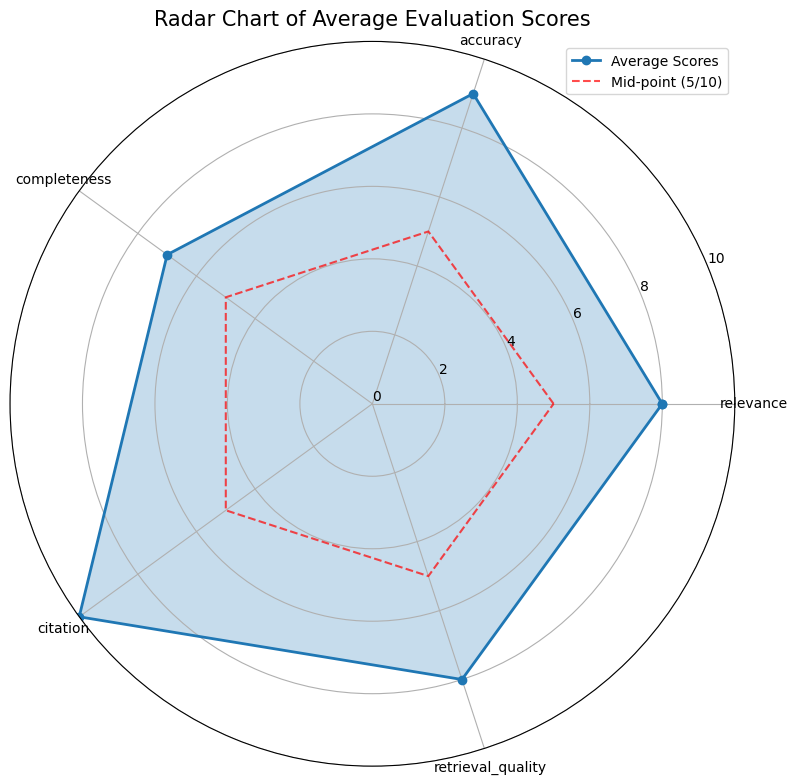

In [ ]:
# Create a radar chart to compare all metrics
def plot_radar_chart(analysis):
    if not analysis:
        print("No analysis data available")
        return
    
    avg_scores = analysis["avg_scores"]
    metrics = [k for k in avg_scores.keys() if k != 'total_score']
    scores = [avg_scores[k] for k in metrics]
    
    # Add the first metric again at the end to close the polygon
    metrics = metrics + [metrics[0]]
    scores = scores + [scores[0]]
    
    # Create the radar chart
    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=True)
    
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))
    ax.plot(angles, scores, 'o-', linewidth=2, label='Average Scores')
    ax.fill(angles, scores, alpha=0.25)
    
    # Add mid-point reference (5/10)
    ax.plot(angles, [5]*len(angles), '--', color='red', alpha=0.7, label='Mid-point (5/10)')
    
    # Customize the chart
    ax.set_thetagrids(angles[:-1] * 180/np.pi, metrics[:-1])
    ax.set_ylim(0, 10)
    ax.set_yticks(range(0, 11, 2))
    ax.grid(True)
    plt.title('Radar Chart of Average Evaluation Scores', size=15)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# Plot radar chart
plot_radar_chart(analysis)

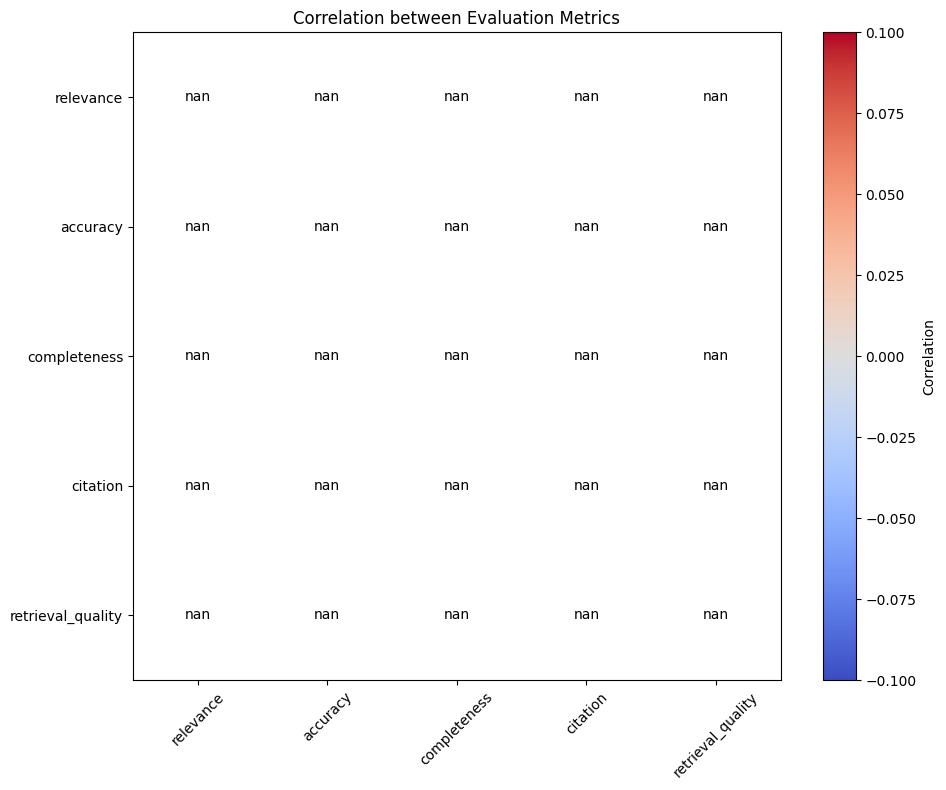

/tmp/ipykernel_3133123/1972490030.py:54: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df['retrieval_quality'], df[metric], 1)
/home/synthesisproject/anaconda3/envs/soroush1/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/tmp/ipykernel_3133123/1972490030.py:54: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df['retrieval_quality'], df[metric], 1)
/tmp/ipykernel_3133123/1972490030.py:54: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df['retrieval_quality'], df[metric], 1)
/tmp/ipykernel_3133123/1972490030.py:54: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df['retrieval_quality'], df[metric], 1)


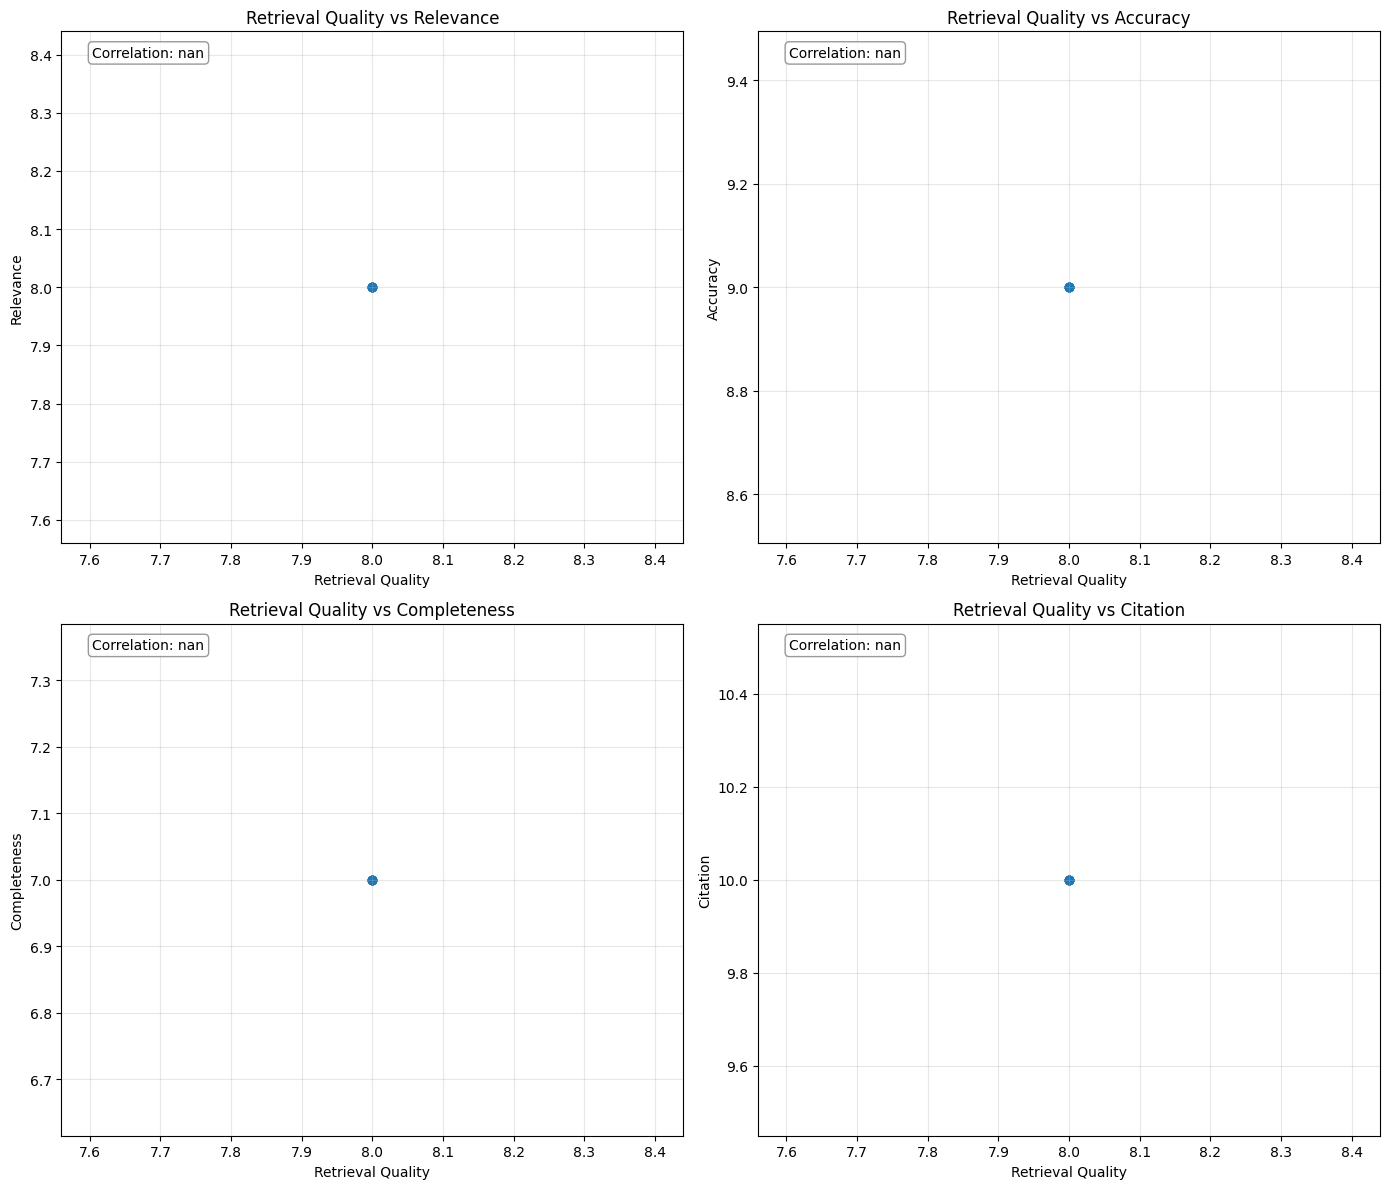

In [ ]:
# Analyze relationship between retrieval quality and other metrics
def analyze_retrieval_impact(results):
    """Analyze how retrieval quality affects other metrics"""
    metrics = ['relevance', 'accuracy', 'completeness', 'citation', 'retrieval_quality']
    data = []
    
    for result in results:
        eval_dict = result.get('evaluation', {})
        if 'error' not in eval_dict and all(m in eval_dict for m in metrics):
            row = {}
            for metric in metrics:
                row[metric] = eval_dict[metric].get('score', 0)
            data.append(row)
    
    if not data:
        print("No valid data for retrieval impact analysis")
        return None
    
    # Convert to DataFrame for easier analysis
    df = pd.DataFrame(data)
    
    # Create correlation matrix
    corr = df.corr()
    
    # Plot correlation heatmap
    plt.figure(figsize=(10, 8))
    plt.imshow(corr, cmap='coolwarm')
    plt.colorbar(label='Correlation')
    plt.xticks(range(len(corr)), corr.columns, rotation=45)
    plt.yticks(range(len(corr)), corr.columns)
    
    # Add correlation values as text
    for i in range(len(corr)):
        for j in range(len(corr)):
            plt.text(j, i, f"{corr.iloc[i, j]:.2f}", 
                     ha="center", va="center", 
                     color="white" if abs(corr.iloc[i, j]) > 0.5 else "black")
    
    plt.title('Correlation between Evaluation Metrics')
    plt.tight_layout()
    plt.show()
    
    # Plot scatter plots for retrieval_quality against other metrics
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    other_metrics = [m for m in metrics if m != 'retrieval_quality']
    
    for i, metric in enumerate(other_metrics):
        ax = axes[i]
        ax.scatter(df['retrieval_quality'], df[metric], alpha=0.6)
        
        # Add trend line
        z = np.polyfit(df['retrieval_quality'], df[metric], 1)
        p = np.poly1d(z)
        ax.plot(df['retrieval_quality'], p(df['retrieval_quality']), "r--")
        
        ax.set_xlabel('Retrieval Quality')
        ax.set_ylabel(metric.capitalize())
        ax.set_title(f'Retrieval Quality vs {metric.capitalize()}')
        ax.grid(True, alpha=0.3)
        
        # Add correlation coefficient
        corr_val = df['retrieval_quality'].corr(df[metric])
        ax.annotate(f'Correlation: {corr_val:.2f}', 
                   xy=(0.05, 0.95), xycoords='axes fraction',
                   bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return df

# Analyze the impact of retrieval quality
retrieval_analysis = analyze_retrieval_impact(evaluation_results)

## 9. Performance Improvement Recommendations

Based on the evaluation results, let's summarize the performance of our RAG system and provide recommendations for improvement.

In [ ]:
# Function to generate performance recommendations based on evaluation results
def generate_recommendations(analysis):
    if not analysis:
        print("No analysis data available for recommendations")
        return
    
    avg_scores = analysis["avg_scores"]
    metrics = [k for k in avg_scores.keys() if k != 'total_score']
    
    # Find the weakest and strongest metrics
    weakest_metric = min(metrics, key=lambda x: avg_scores[x])
    strongest_metric = max(metrics, key=lambda x: avg_scores[x])
    
    print(f"\n{'='*50}")
    print("RAG System Performance Summary and Recommendations")
    print(f"{'='*50}")
    
    print(f"\nPerformance Summary:")
    print(f"- Evaluated {analysis['valid_results']} valid responses out of {analysis['total_evaluations']} total queries")
    print(f"- Average total score: {avg_scores.get('total_score', 0):.2f}")
    print(f"- Strongest area: {strongest_metric.capitalize()} with score {avg_scores[strongest_metric]:.2f}/10")
    print(f"- Weakest area: {weakest_metric.capitalize()} with score {avg_scores[weakest_metric]:.2f}/10")
    
    print(f"\nImprovement Recommendations:")
    
    # Retrieval quality recommendations
    retrieval_score = avg_scores.get('retrieval_quality', 0)
    print(f"1. Retrieval System (Current score: {retrieval_score:.2f}/10):")
    if retrieval_score < 5:
        print("   - Critical improvement needed in document retrieval")
        print("   - Consider using a different embedding model (e.g., domain-specific embeddings)")
        print("   - Increase chunk overlap when processing documents")
    elif retrieval_score < 7:
        print("   - Moderate improvement needed in document retrieval")
        print("   - Experiment with different k values when retrieving documents")
        print("   - Try hybrid retrieval approaches (keyword + semantic)")
    else:
        print("   - Retrieval system is performing well")
        print("   - Consider fine-tuning to further improve domain-specific retrieval")
    
    # Response generation recommendations
    accuracy_score = avg_scores.get('accuracy', 0)
    relevance_score = avg_scores.get('relevance', 0)
    completeness_score = avg_scores.get('completeness', 0)
    avg_response_score = (accuracy_score + relevance_score + completeness_score) / 3
    
    print(f"\n2. Response Generation (Current avg score: {avg_response_score:.2f}/10):")
    if avg_response_score < 5:
        print("   - Critical improvement needed in response generation")
        print("   - Consider using a more powerful LLM")
        print("   - Revise the RAG prompt to improve answer quality")
    elif avg_response_score < 7:
        print("   - Moderate improvement needed in response generation")
        print("   - Experiment with prompt engineering to improve coherence")
        print("   - Adjust temperature/sampling parameters for better quality")
    else:
        print("   - Response generation is performing well")
        print("   - Consider adding a post-processing step for consistency checking")
    
    # Citation recommendations
    citation_score = avg_scores.get('citation', 0)
    print(f"\n3. Citation (Current score: {citation_score:.2f}/10):")
    if citation_score < 5:
        print("   - Critical improvement needed in source citation")
        print("   - Explicitly instruct the model to include DOIs in the RAG prompt")
        print("   - Consider post-processing to ensure citations are included")
    elif citation_score < 7:
        print("   - Moderate improvement needed in citation practices")
        print("   - Enhance prompt to emphasize the importance of proper citation")
    else:
        print("   - Citation system is performing well")
        print("   - Consider adding a structured citation format for consistency")
    
    print(f"\n4. Overall System Improvements:")
    print("   - Consider domain-specific fine-tuning of the embedding model")
    print("   - Experiment with different chunking strategies for documents")
    print("   - Implement a query rewriting step to improve retrieval")
    print("   - Add a re-ranking step after initial retrieval")

# Generate recommendations based on the analysis
generate_recommendations(analysis)


RAG System Performance Summary and Recommendations

Performance Summary:
- Evaluated 11 valid responses out of 100 total queries
- Average total score: 42.00
- Strongest area: Citation with score 10.00/10
- Weakest area: Completeness with score 7.00/10

Improvement Recommendations:
1. Retrieval System (Current score: 8.00/10):
   - Retrieval system is performing well
   - Consider fine-tuning to further improve domain-specific retrieval

2. Response Generation (Current avg score: 8.00/10):
   - Response generation is performing well
   - Consider adding a post-processing step for consistency checking

3. Citation (Current score: 10.00/10):
   - Citation system is performing well
   - Consider adding a structured citation format for consistency

4. Overall System Improvements:
   - Consider domain-specific fine-tuning of the embedding model
   - Experiment with different chunking strategies for documents
   - Implement a query rewriting step to improve retrieval
   - Add a re-ranking s

: 

## 10. Conclusion

In this notebook, we've implemented the LLM as judge framework from Mrigi 11 to evaluate our RAG system on zeolite synthesis queries. The evaluation framework has provided valuable insights into the performance of our system, including its strengths and areas for improvement.

### Key Findings:

1. **Retrieval Quality**: We measured how well our system retrieves relevant context for synthesis questions.
2. **Response Quality**: We evaluated the relevance, accuracy, and completeness of generated answers.
3. **Citation Practices**: We assessed how well the system attributes information to original sources.

### Next Steps:

Based on the analysis and recommendations, we can focus on improving the weakest aspects of our system to enhance overall performance. This might include:

- Refining the embedding model for better retrieval
- Adjusting chunking strategies for document processing
- Enhancing the RAG prompt to improve response quality
- Implementing query rewriting or re-ranking mechanisms

The LLM as judge framework provides an efficient way to evaluate and iterate on RAG system improvements without requiring extensive human evaluation.